# Lab 07: Helicopter Drop

Welcome to Lab 07.

<div style="background-color:#f2d8b2; border-left:6px solid #b36a00; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>ℹ️ Appropriate collaboration and AI usage</b><br>
<span style="font-size:0.9em;">You are welcome to collaborate with other students on this lab, as long as each student writes their own solutions. Consult with your teacher and course syllabus for information and policies regarding appropriate use of AI tools and submission of late work.</span>
</div>

In [1]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## 1. A/B Testing

A/B testing is a form of hypothesis testing that allows you to make comparisons between two numerical distributions. It is also called a permutation test.

You'll almost never be explicitly asked to perform an A/B test by name, much like other forms of hypothesis testing. Make sure you can identify situations where this type of test is appropriate and know how to correctly implement each step. Remember, the goal of an A/B test is to determine if two samples came from the same underlying distribution, or from different distributions.

### Question 1.1.

The following statements are the unordered steps of an A/B hypothesis test:

1. Choose a test statistic (typically the difference in means between two categories)

2. Shuffle the labels of the original sample, find your simulated test statistic, and repeat many times

3. Find the value of the observed test statistic

4. Calculate the p-value based off your observed and simulated test statistics

5. Define a null and alternate model

6. Use the p-value and p-value cutoff to draw a conclusion about the null hypothesis

Make an array called `ab_test_order` that contains the correct order of an A/B test, where the first item of the array is the first step of an A/B test and the last item of the array is the last step of an A/B test.


In [2]:
ab_test_order = make_array(5, 1, 3, 2, 4, 6) # SOLUTION

In [3]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `ab_test_order` has the correct number of elements in it
failure_message: ❌ `ab_test_order` does not have the correct number of elements in it
""" # END TEST CONFIG

len(ab_test_order) == 6

True

In [4]:
""" # BEGIN TEST CONFIG
hidden: hidden
points: 1
""" # END TEST CONFIG

all(np.array([5, 1, 3, 2, 4, 6]) == ab_test_order)

True

### Question 1.2.

If the null hypothesis of an A/B test is correct, what value would be expected, on average, when computing the difference in means between the two categories?

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** Under the null model, there should be no statistically significant difference between the grouped means so one would expect the difference between the means to be 0 on average.

### Question 1.3

Why do we shuffle labels in an A/B test? 


<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** We shuffle labels as a way to resample the original data, and understand the distribution of the difference in means under the assumptions of the null hypothesis. That way, we know how significant the observed difference of means is in context of the distributions of possible outcomes.

## 2. Paper Helicopters

The Paper Helicopter Experiment (https://www.paperhelicopterexperiment.com/) provides different templates for constructing paper helicopters that can be dropped. The designs can be modified to create helicopters with different dimensions for the wings, body, weighting, and more. In this lab you'll investigate whether the length of the rotor and the amount of weight attached to the helicopter result in a difference in the time it takes to fall from a 3rd floor stairwell. To conduct your analysis, you'll use an A/B test.

### The Data
This data was collected by a group of NCSSM-Online students during an online weekend held October 2nd, 2021. Five groups of students dropped 143 paper helicopters in total. There were 4 unique configurations that were assigned to the groups, one per group.

1. The Default: Full length (long) rotors, unweighted body
2. The Short: Short rotors, unweighted body
3. The Heavy: Long rotors, weighted body
4. The Short Heavy: Short rotors, weighted body

The following features were recorded for each helicopter dropped:
* `Rotor`: Long or Short (string). Indicates if the helicopter had full length or shortened rotors.
* `Weight`: Weighted or Unweighted (string). Indicates if the helicopter had a weighted (3 paperclips) or unweighted body.
* `Team`: 1, 2, 3, 4, or 5 (int). Indicates which team dropped the helicopter.
* `Location`: Side A or Side B (string). Indicates which side of the building the helicopters were dropped from.
* `Obstruction`: True or False (Boolean). Indicates if the helicopter hit the stairwell or other object on the way down.
* `Time`: (Float). Time, measured in seconds, it took for the helicopter to hit the ground after being released.

Run the following cell to load the data in as the table named `helicopters_raw_data`.

In [5]:
helicopters_raw_data = Table.read_table('helicopters.csv')
helicopters_raw_data

Rotor,Weight,Team,Location,Obstruction,Time
Long,Unweighted,1,Side A,False,4.93
Long,Unweighted,1,Side A,False,4.07
Long,Unweighted,1,Side A,True,1.17
Long,Unweighted,1,Side A,True,4.91
Long,Unweighted,1,Side A,True,4.4
Long,Unweighted,1,Side A,False,5.41
Long,Unweighted,1,Side A,False,4.99
Long,Unweighted,1,Side A,False,5.8
Long,Unweighted,1,Side A,False,5.94
Long,Unweighted,1,Side A,False,5.14


You'll notice that due to variation in the helicopter construction, wind/weather, and randomness of the universe not every drop time was identical, even for the helicopters with the same configurations. Let's explore the data a bit to see how the drop times varied.

### Question 2.1.

Let's start by cleaning the data a little. This dataset has several measurements taken where the helicopter hit the stairwell, a nearby building, or some other obstruction that impacted the fall time. These results should be discarded since they might introduce unexpected variation in the fall times that would impact the ability to draw a causal inference from the analysis that follows.

Create a new table called `helicopters` that only contains the rows of `helicopters_raw_data` that correspond to a helicopter that did **not** hit an obstruction during the fall.

In [6]:
helicopters = helicopters_raw_data.where('Obstruction', False) # SOLUTION
helicopters

Rotor,Weight,Team,Location,Obstruction,Time
Long,Unweighted,1,Side A,False,4.93
Long,Unweighted,1,Side A,False,4.07
Long,Unweighted,1,Side A,False,5.41
Long,Unweighted,1,Side A,False,4.99
Long,Unweighted,1,Side A,False,5.8
Long,Unweighted,1,Side A,False,5.94
Long,Unweighted,1,Side A,False,5.14
Long,Unweighted,1,Side A,False,5.53
Long,Unweighted,1,Side A,False,6.3
Short,Weighted,2,Side A,False,3.41


In [7]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `helicopters` has the correct number of rows in it
failure_message: ❌ `helicopters` does not have the correct number of rows in it. Did you correctly remove the obstruction rows?
""" # END TEST CONFIG

helicopters.num_rows

130

In [8]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `helicopters` does not have any True values in the "Obstruction" column.
failure_message: ❌ `helicopters` has at least one True value in the "Obstruction" column.
""" # END TEST CONFIG

all(helicopters.column('Obstruction') == False)

True

### Question 2.2
Suppose you're interested in determining how the rotor length might impact fall time. Start by creating a histogram that displays the distribution of times for helicopters with long and short rotors, overlaid. Use the provided bins stored to `my_bins` and the `group` argument to create the necessary histogram.

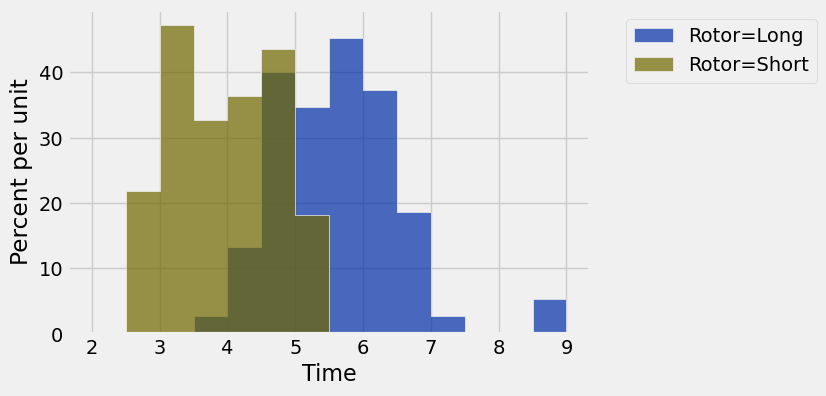

In [9]:
my_bins = np.arange(2, 9.5, 0.5)
helicopters.hist('Time', bins=my_bins, group="Rotor" ) # SOLUTION

You can see it's fairly easy to compare these two distributions now that they're on the same scale and set of axes.

## 3. The Rotor Question

You might now be wondering if there is a difference between the fall times of helicopters with long (full length) vs. short rotors. It certainly appears that the distributions *might* be different than each other, but visual inspection can often be deceiving.  Use the set of collected data to make a more statistically rigorous determination.

### Running an experiment

We are going to run the following hypothesis test to determine either the association or causal link between the rotor length of a helicopter and the time it takes to fall to the ground. We are going to use the following null and alternative hypotheses:

**Null hypothesis**: The distribution of fall times for helicopters with long rotors is the same as for helicopters with short rotors.

**Alternative hypothesis**: Helicopters with long rotors take more time to fall to the ground on average.

Our alternative hypothesis is related to our suspicion that helicopters with long rotors fall slower, since there is more material to cause resistance against the air as the helicopter falls to the ground.

### Question 3.1.

Why is an A/B test appropriate for this situation? What would you use as the "A" group (the control group) and which group is the "B" group (the treatment group)?

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** An A/B test is appropriate because we are comparing 2 distributions of numerical data. The "A" group is full length rotors. The "B" group is the short rotors. 

### Question 3.2.

We want to figure out if there is a difference between the distribution of fall times for full length and shortened rotor helicopters. Specifically, we want to test if fall times were longer for longer rotor helicopters than they were for shorter rotor helicopters. 

What should the test statistic be to test this hypothesis? What values of this statistic would support the alternative hypothesis?

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** We want to find the difference between the mean fall times. Low values of this difference support the null. High values of this difference support the alternative.

### Question 3.3.

Create a Table named `time_means` that contains the average fall time for both categories of helicopters: full length rotor helicopters, and the shortened rotor helicopters. The Table should have two columns: one indicating the rotor length, and one that contains the average fall time for the corresponding group.

**Hint:** Use a combination of `.select()` and `.group()` to generate this Table.

In [10]:
time_means = helicopters.select("Rotor", "Time").group('Rotor', np.average) # SOLUTION
time_means

Rotor,Time average
Long,5.61067
Short,3.96364


In [11]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.2
success_message: ✅ `time_means` has the correct number of rows
failure_message: ❌ `time_means` does not have the correct number of rows. Use `.group` and select the "Rotor" column.
""" # END TEST CONFIG

time_means.num_rows

2

In [12]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.4
success_message: ✅ `time_means` has the correct value in the Long row
failure_message: ❌ `time_means` does not have the correct value in the Long row
""" # END TEST CONFIG

np.isclose(time_means.where("Rotor", "Long").column(1).item(0), 5.610666666666667)

True

In [13]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.4
success_message: ✅ `time_means` has the correct value in the Short row
failure_message: ❌ `time_means` does not have the correct value in the Short row
""" # END TEST CONFIG

np.isclose(time_means.where("Rotor", "Short").column(1).item(0), 3.963636363636364)

True

### Question 3.4.

Calculate the test statistic for our observed data using the `time_means` table. Set `observed_difference` to the value you compute. 


In [14]:
# BEGIN SOLUTION NO PROMPT
means = time_means.column(1)
# END SOLUTION
observed_difference = means.item(0) - means.item(1) # SOLUTION
observed_difference

1.647030303030303

In [15]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `observed_difference` has the correct value
failure_message: ❌ `observed_difference` does not have the correct value
""" # END TEST CONFIG

np.isclose(observed_difference, 1.647030303030303)

True

### Question 3.5.

To perform an A/B test, we'll need to compute similar statistics for the many simulations we'll run. Writing a function which returns a test statistic will be a great way to save time. Write a function named `find_test_stat` which takes in the arguments `table`, `labels_col`, and `values_col` that calculates the test statistic required for A/B testing.

The `table` passed into this function will be a permutation of our original table and structured the same way. `labels_col` will be passed a string that matches the column label in `table` that contains the labels of the categories you'll be grouping by. `values_col` will be passed a string that matches the column label that contains the values that you'll be using to compute the test statistic.

When you've written this function, you must be able to pass it any table and two specified column labels and the function should compute a test statistic required for an A/B test, not just for this problem, but any problem! For example, running `find_test_stat(helicopters, "Rotor", "Time")` should return the exact same test statistic you generated in an earlier question and running `find_test_stat(helicopters, "Weight", "Time")` would compute the test statistic based on the groups of time and **"Weight"** columns.

In [16]:
def find_test_stat(table, labels_col, values_col):
    # BEGIN SOLUTION
    reduced = table.select(labels_col, values_col)
    means_table = reduced.group(labels_col, np.average)
    means = means_table.column(1)
    return means.item(0) - means.item(1)
    # END SOLUTION

find_test_stat(helicopters, "Rotor", "Time")

1.647030303030303

In [17]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `find_test_stat` returns the correct value for the statistic for the "Rotor" and "Time" columns
failure_message: ❌ `find_test_stat` does not return the correct value for the statistic for the "Rotor" and "Time" columns
""" # END TEST CONFIG

np.isclose(find_test_stat(helicopters, "Rotor", "Time"), 1.647030303030303)

True

In [18]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `find_test_stat` returns the correct value for the statistic for the "Weight" and "Time" columns
failure_message: ❌ `find_test_stat` does not return the correct value for the statistic for the "Weight" and "Time" columns
""" # END TEST CONFIG

np.isclose(find_test_stat(helicopters, "Weight", "Time"), 0.9997304582210234)

True

### Question 3.6.

Write a function `simulate_and_test_statistic` to compute one trial of our A/B test. Your function should run a simulation and return a test statistic.

**Hint:** You can "shuffle" the labels by using `.sample(with_replacement = False)` on the entire Table, and then select the column that contains the newly shuffled labels. Then, you can either overwrite the existing labels, **or**, extend the table with a new column labeled something similar to "shuffled labels". Just make sure you pass the correct label on to the `find_test_stat` function!

Note: The autograder test here is fairly lenient. If you have an issue with the following questions, make sure to take a look at your answer to the previous question. Specifically, make sure that you are taking the directionality of our alternative hypothesis into account, meaning, check the order in which you are subtracting the average times.

In [19]:
def simulate_and_test_statistic(table, labels_col, values_col):
    # BEGIN SOLUTION
    shuffled_labels = table.sample(with_replacement = False).column(labels_col)
    original_and_shuffled = table.with_column("shuffled labels", shuffled_labels)
    return find_test_stat(original_and_shuffled, "shuffled labels", values_col)
    # END SOLUTION
    
simulate_and_test_statistic(helicopters, "Rotor", "Time")

-0.14397575757575787

In [20]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `simulate_and_test_statistic` appears to correctly simulate values under the null hypothesis based on 1000 simulations
failure_message: ❌ `simulate_and_test_statistic` does not appear to correctly simulate values under the null hypothesis based on 1000 simulations
""" # END TEST CONFIG

abs(np.mean([simulate_and_test_statistic(helicopters, "Rotor", "Time") for i in range(1000)])) < 0.02 and 0.19 <= np.std([simulate_and_test_statistic(helicopters, "Rotor", "Time") for i in range(1000)]) <= 0.25

True

### Question 3.7.

Use the `simulate_and_test_statistic` to simulate 5,000 trials of our A/B test and assign an array of the test statistics to `differences`.

In [21]:
# This cell might take a couple seconds to run
differences = make_array()
# BEGIN SOLUTION
repetitions = 5000
for i in np.arange(repetitions):
    new_difference = simulate_and_test_statistic(helicopters, "Rotor", "Time")
    differences = np.append(differences, new_difference)
# END SOLUTION
differences

array([ 0.16707879, -0.06266667, -0.0078303 , ...,  0.07347879,
        0.12201212, -0.19912727])

In [22]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ `differences` contains 5000 statistics
failure_message: ❌ `differences` does not contain 5000 statistics. Are you appending each statistic to the array?
""" # END TEST CONFIG

len(differences) == 5000

True

In [23]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.5
success_message: ✅ The statistics in `differences` appear to be correctly simulated based on your 5000 simulations
failure_message: ❌ The statistics in `differences` do not appear to be correctly simulated based on your 5000 simulations
""" # END TEST CONFIG

abs(np.average(differences)) < 0.02

True

Run the cell below to view a histogram of your simulated test statistics plotted with your observed test statistic. Think about what this might imply about the p-value and if there is sufficient evidence to reject the null hypothesis.

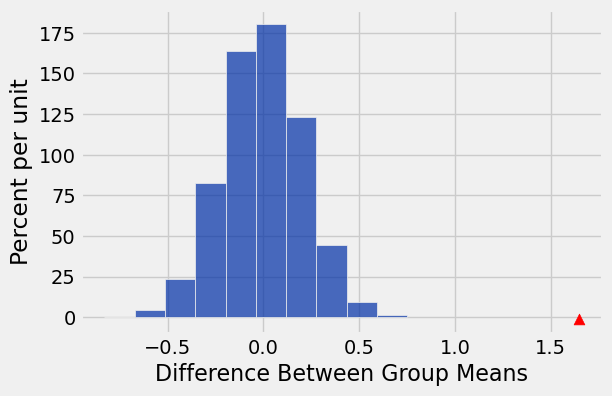

In [24]:
Table().with_column('Difference Between Group Means', differences).hist()
plt.scatter(observed_difference, -0.01, color = 'red', s = 60, marker="^", zorder = 2);

### Question 3.8.

Compute the empirical p-value using the statistics from your simulation and the observed value of the test statistic. Assign it to `empirical_p`

In [25]:
empirical_p = np.count_nonzero(differences >= observed_difference) / repetitions # SOLUTION
empirical_p

0.0

In [26]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `empirical_p` is larger than 0 and sufficiently small to be reasonable
failure_message: ❌ `empirical_p` is not larger than 0, or is not small enough to be reasonable
""" # END TEST CONFIG

empirical_p < 0.01

True

### Question 3.9.

Your p-value should have been very small, perhaps even 0! Since this value is less than the standard p-value cutoff of 5 percent, we would reject the null hypothesis. Is there enough evidence to claim that the difference in rotor length **causes** the difference in fall time, or does it just show association? Explain your answer using both the design of the experiment and the result of the A/B test.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** We didn't run a randomized controlled experiment, so we can't quite claim a causal effect. We may be misled by confounding factors or reverse causation.

## 4. Bonus Investigation (Optional, Not graded)

Collect your own helicopter data as part of a class activity. Load the data in the cell below and perform a similar A/B test using *your* data. You should be able to use the functions you wrote as part of this lab activity to quickly perform an analysis.

In [27]:
# Your analysis could go here if you choose to complete it.


Complete a similar analysis by:

* selecting a category to group your data by (rotor length, color of paper, weight of helicopter, etc.)
* computing the observed value of the test statistic
* simulating 5,000 A/B tests to create a distribution of the test statistic under the assumptions of the null hypothesis
* compute the empirical p-value
* determine if there is a difference in the drop times between the two groups in the selected category.

# Submitting your work
You're done with this assignment! Assignments should be turned in using the following best practices:
1. Save your notebook.
2. Restart the kernel and run all cells up to this one.
3. Run the cell below with the code `grader.export(...)`. This will re-run all the tests. Make sure they are passing as you expect them to.
4. Download the file named `lab07_<date-time-stamp>.zip`, found in the explorer pane on the left side of the screen. **Note**: If clicking on the link in this notebook results in an error, try downloading the file from the file explorer panel on the left.
5. Upload `lab07_<date-time-stamp>.zip` to the corresponding assignment on Canvas.